# MCMC do zero: Metropolis-Hastings

**Tema:** Estatística › Estatística Bayesiana

Fora dos casos conjugados, a posteriori não tem forma fechada: o denominador
$P(D)$ é uma integral que ninguém resolve em dimensão alta.

A saída é não calcular a posteriori, e sim **amostrar** dela. Este notebook
implementa Metropolis-Hastings em ~15 linhas, mostra que ele funciona, e —
mais importante — mostra **como ele falha em silêncio** e como diagnosticar.

> **A ideia central:** para decidir se aceito um novo valor, só preciso da
> **razão** entre posterioris. E na razão, $P(D)$ cancela. É por isso que o
> método funciona sem nunca calcular a integral impossível.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(4242)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("pronto")

pronto


## 1. O algoritmo inteiro

1. Comece em um $\theta_0$ qualquer.
2. Proponha $\theta^* = \theta_t + \varepsilon$, com $\varepsilon$ gaussiano.
3. Calcule $r = \dfrac{P(D \mid \theta^*)\,P(\theta^*)}{P(D \mid \theta_t)\,P(\theta_t)}$.
4. Aceite com probabilidade $\min(1, r)$; senão, **repita o ponto atual**.
5. Volte ao passo 2.

Trabalhamos em **log** para não estourar o ponto flutuante: a razão vira
diferença, e a aceitação vira $\log u < \log r$.

In [2]:
def metropolis(log_posteriori, inicio, n_passos, passo, semente=0):
    """Metropolis com proposta gaussiana simétrica. Devolve cadeia e taxa de aceitação."""
    gerador = np.random.default_rng(semente)
    theta = np.atleast_1d(np.asarray(inicio, dtype=float))
    log_p = log_posteriori(theta)

    cadeia = np.empty((n_passos, theta.size))
    aceitos = 0
    for t in range(n_passos):
        proposta = theta + gerador.normal(0, passo, size=theta.size)
        log_p_prop = log_posteriori(proposta)
        # aceita se a proposta for melhor, ou às vezes mesmo se for pior
        if np.log(gerador.random()) < log_p_prop - log_p:
            theta, log_p = proposta, log_p_prop
            aceitos += 1
        cadeia[t] = theta
    return cadeia, aceitos / n_passos


print("15 linhas. É esse o algoritmo que sustenta Stan, PyMC e NumPyro.")

15 linhas. É esse o algoritmo que sustenta Stan, PyMC e NumPyro.


## 2. Teste de sanidade: um caso que sabemos resolver

Antes de usar MCMC em algo difícil, valide contra um caso com resposta
analítica. Aqui: Beta-Binomial, cuja posteriori exata conhecemos.

taxa de aceitação: 0.642

                     MCMC      exata
média             0.17751    0.17717
desvio            0.02381    0.02391
p2.5              0.13276    0.13279
p50               0.17689    0.17632
p97.5             0.22642    0.22635


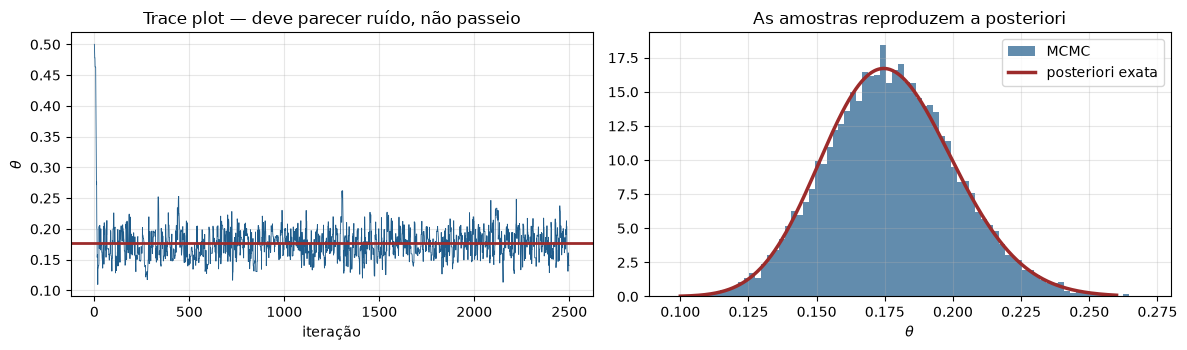

In [3]:
N_ENSAIOS, K_SUCESSOS = 250, 43
A_PRIORI, B_PRIORI = 2, 2


def log_post_beta_binomial(theta):
    p = theta[0]
    if not (0 < p < 1):
        return -np.inf
    return (stats.binom.logpmf(K_SUCESSOS, N_ENSAIOS, p)
            + stats.beta.logpdf(p, A_PRIORI, B_PRIORI))


cadeia, taxa = metropolis(log_post_beta_binomial, inicio=[0.5],
                          n_passos=40_000, passo=0.03, semente=7)
BURN_IN = 4_000
amostras = cadeia[BURN_IN:, 0]

exata = stats.beta(A_PRIORI + K_SUCESSOS, B_PRIORI + N_ENSAIOS - K_SUCESSOS)
print(f"taxa de aceitação: {taxa:.3f}\n")
print(f"{'':<14s} {'MCMC':>10s} {'exata':>10s}")
print(f"{'média':<14s} {amostras.mean():>10.5f} {exata.mean():>10.5f}")
print(f"{'desvio':<14s} {amostras.std():>10.5f} {exata.std():>10.5f}")
for q in (2.5, 50, 97.5):
    print(f"{'p'+str(q):<14s} {np.percentile(amostras, q):>10.5f} "
          f"{exata.ppf(q/100):>10.5f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(cadeia[:2500, 0], color=AZUL, lw=0.6)
axes[0].axhline(exata.mean(), color=VERMELHO, lw=2)
axes[0].set_xlabel("iteração"); axes[0].set_ylabel(r"$\theta$")
axes[0].set_title("Trace plot — deve parecer ruído, não passeio")

g = np.linspace(0.10, 0.26, 500)
axes[1].hist(amostras, bins=80, density=True, color=AZUL, alpha=0.7, label="MCMC")
axes[1].plot(g, exata.pdf(g), color=VERMELHO, lw=2.5, label="posteriori exata")
axes[1].set_xlabel(r"$\theta$"); axes[1].legend()
axes[1].set_title("As amostras reproduzem a posteriori")
plt.tight_layout(); plt.show()

Quatro casas decimais de acordo com a solução exata. **Sempre faça esse teste**
antes de confiar em MCMC num modelo que você não sabe resolver — é a única
forma de validar a sua implementação.

## 3. O tamanho do passo decide tudo

É aqui que MCMC quebra na prática. Passo pequeno demais: a cadeia rasteja e as
amostras são quase idênticas. Passo grande demais: quase tudo é rejeitado e a
cadeia trava em degraus.

passo 0.002  aceitação  96.7%   autocorr(1)  0.996   ESS ≈       49 de 18000


passo 0.03   aceitação  64.8%   autocorr(1)  0.704   ESS ≈     3036 de 18000


passo 0.5    aceitação   5.9%   autocorr(1)  0.923   ESS ≈      755 de 18000


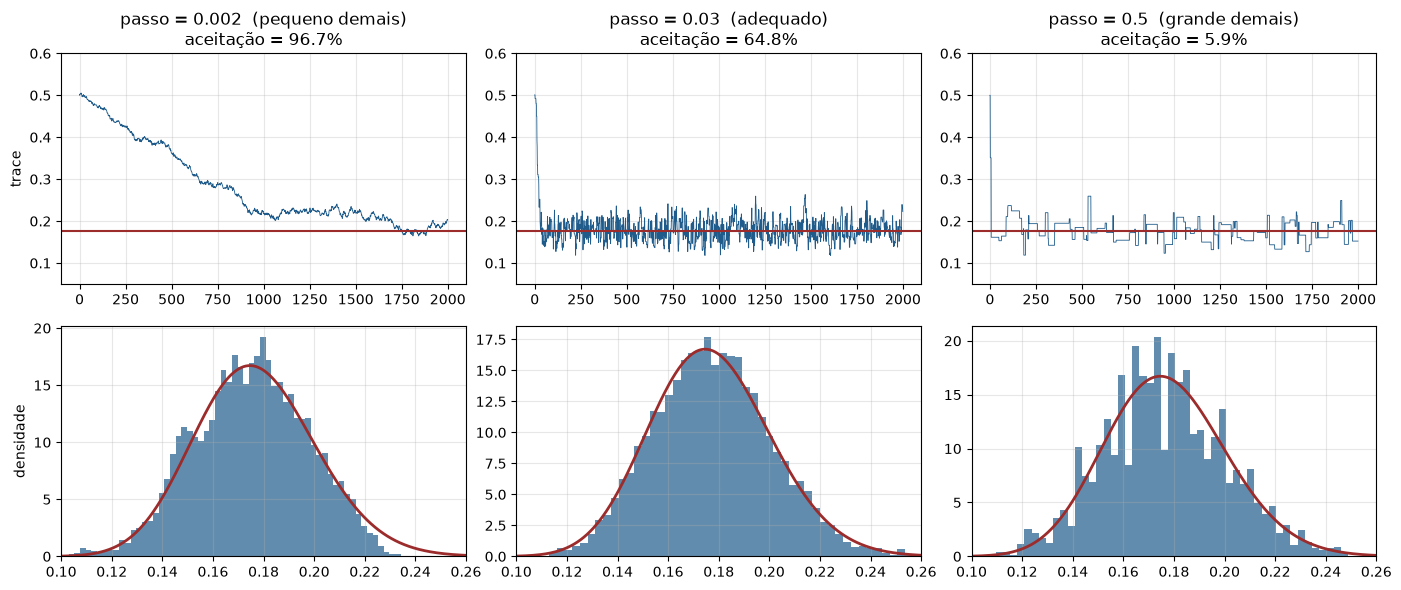

In [4]:
PASSOS = [0.002, 0.03, 0.5]
ROTULOS = ["pequeno demais", "adequado", "grande demais"]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for j, (passo, rotulo) in enumerate(zip(PASSOS, ROTULOS)):
    c, taxa_j = metropolis(log_post_beta_binomial, [0.5], 20_000, passo, semente=11)
    am = c[2000:, 0]

    axes[0, j].plot(c[:2000, 0], color=AZUL, lw=0.6)
    axes[0, j].axhline(exata.mean(), color=VERMELHO, lw=1.5)
    axes[0, j].set_title(f"passo = {passo}  ({rotulo})\naceitação = {taxa_j:.1%}")
    axes[0, j].set_ylim(0.05, 0.6)

    axes[1, j].hist(am, bins=60, density=True, color=AZUL, alpha=0.7)
    axes[1, j].plot(g, exata.pdf(g), color=VERMELHO, lw=2)
    axes[1, j].set_xlim(0.10, 0.26)

    # autocorrelação e tamanho efetivo de amostra
    centrado = am - am.mean()
    acf = np.correlate(centrado, centrado, "full")[len(centrado) - 1:]
    acf /= acf[0]
    corte = np.argmax(acf < 0.05) if (acf < 0.05).any() else len(acf)
    ess = len(am) / (1 + 2 * acf[1:corte].sum())
    print(f"passo {passo:<6} aceitação {taxa_j:>6.1%}   "
          f"autocorr(1) {acf[1]:>6.3f}   ESS ≈ {ess:>8.0f} de {len(am)}")

axes[0, 0].set_ylabel("trace"); axes[1, 0].set_ylabel("densidade")
plt.tight_layout(); plt.show()

**Como ler os três casos:**

- **Passo pequeno:** aceitação altíssima (>95%), mas cada passo anda quase
  nada. Autocorrelação perto de 1 e ESS ridículo — 20.000 amostras que valem
  por algumas dezenas.
- **Passo adequado:** aceitação em torno de 40%, trace parecendo ruído branco,
  ESS na casa dos milhares.
- **Passo grande:** quase tudo rejeitado, a cadeia fica parada por centenas de
  iterações e o trace vira uma escada.

> **Alvos de referência:** taxa de aceitação ~44% em uma dimensão, ~23% em
> dimensão alta. ESS de pelo menos algumas centenas por parâmetro. Se a
> aceitação está fora de 20–50%, ajuste o passo antes de olhar qualquer
> resultado.

## 4. Um problema sem conjugada: dois parâmetros

Agora o caso real: estimar $\mu$ **e** $\sigma$ de dados normais, com prioris
próprias. Não há conjugada simples aqui — e o MCMC nem percebe a diferença.

taxa de aceitação: 0.360   (alvo ~0,23 em 2D)

parâmetro    verdade  média post.                     IC 95%
mu             72.00       71.602   [  69.279,   73.985]
sigma           9.00        9.562   [   7.978,   11.529]


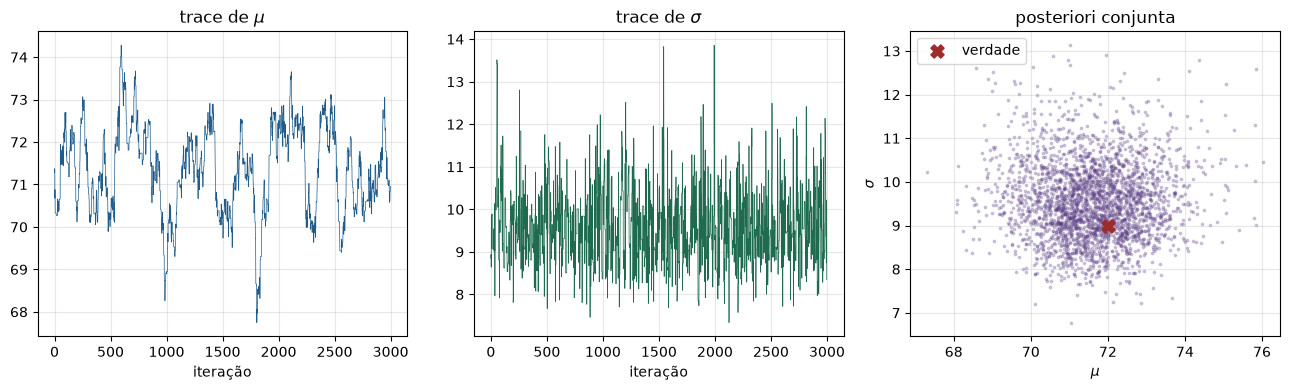

In [5]:
dados = rng.normal(loc=72.0, scale=9.0, size=60)


def log_post_normal(theta):
    mu, log_sigma = theta
    sigma = np.exp(log_sigma)      # amostrar em log evita a fronteira sigma > 0
    lp = stats.norm.logpdf(mu, 70, 20).sum()          # priori de mu
    lp += stats.halfnorm.logpdf(sigma, scale=15)      # priori de sigma
    lp += log_sigma                                   # jacobiano da transformação
    return lp + stats.norm.logpdf(dados, mu, sigma).sum()


cadeia2, taxa2 = metropolis(log_post_normal, inicio=[60.0, np.log(5.0)],
                            n_passos=60_000, passo=0.28, semente=3)
pos = cadeia2[6000:]
mu_post, sigma_post = pos[:, 0], np.exp(pos[:, 1])

print(f"taxa de aceitação: {taxa2:.3f}   (alvo ~0,23 em 2D)\n")
print(f"{'parâmetro':<10s} {'verdade':>9s} {'média post.':>12s} {'IC 95%':>26s}")
for nome, verdade, am in [("mu", 72.0, mu_post), ("sigma", 9.0, sigma_post)]:
    ic = np.percentile(am, [2.5, 97.5])
    print(f"{nome:<10s} {verdade:>9.2f} {am.mean():>12.3f}   [{ic[0]:>8.3f}, {ic[1]:>8.3f}]")

fig = plt.figure(figsize=(13, 4))
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(pos[:3000, 0], color=AZUL, lw=0.5)
ax1.set_title(r"trace de $\mu$"); ax1.set_xlabel("iteração")

ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(np.exp(pos[:3000, 1]), color=VERDE, lw=0.5)
ax2.set_title(r"trace de $\sigma$"); ax2.set_xlabel("iteração")

ax3 = fig.add_subplot(1, 3, 3)
ax3.scatter(mu_post[::20], sigma_post[::20], s=3, alpha=0.25, color=ROXO)
ax3.scatter([72], [9], color=VERMELHO, s=90, marker="X", zorder=3, label="verdade")
ax3.set_xlabel(r"$\mu$"); ax3.set_ylabel(r"$\sigma$")
ax3.set_title("posteriori conjunta"); ax3.legend()
plt.tight_layout(); plt.show()

**Dois detalhes técnicos que valem para qualquer modelo:**

1. **Amostre $\log \sigma$, não $\sigma$.** A restrição $\sigma > 0$ faria a
   cadeia bater na parede e rejeitar propostas o tempo todo. Reparametrizar
   para a reta inteira é padrão em toda biblioteca séria.
2. **Não esqueça o jacobiano.** Ao mudar de variável, a densidade muda por
   $|d\sigma/d\log\sigma| = \sigma$, e o termo `+ log_sigma` é isso em log.
   Esquecê-lo produz uma posteriori sutilmente errada — e nada avisa.

## 5. Diagnóstico: R-hat e múltiplas cadeias

Uma cadeia que parece boa pode estar presa numa região do espaço. A defesa é
rodar **várias cadeias de pontos iniciais bem diferentes** e verificar se elas
concordam. A estatística $\hat{R}$ compara a variância *entre* cadeias com a
variância *dentro* de cada uma.

R-hat de mu: 1.00082   (alvo < 1,01)


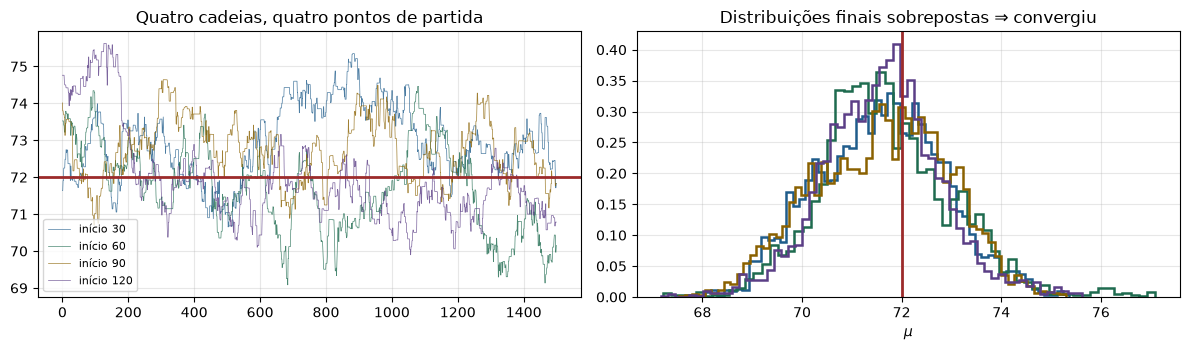

In [6]:
def r_hat(cadeias):
    """cadeias: array (n_cadeias, n_amostras). R-hat ~ 1 indica convergência."""
    m, n = cadeias.shape
    medias, variancias = cadeias.mean(axis=1), cadeias.var(axis=1, ddof=1)
    B = n * medias.var(ddof=1)          # variância ENTRE cadeias
    W = variancias.mean()               # variância DENTRO das cadeias
    var_post = (n - 1) / n * W + B / n
    return np.sqrt(var_post / W)


inicios = [30.0, 60.0, 90.0, 120.0]
cadeias_mu = np.array([
    metropolis(log_post_normal, [inicio, np.log(5.0)], 20_000, 0.28, semente=s)[0][4000:, 0]
    for s, inicio in enumerate(inicios)])

print(f"R-hat de mu: {r_hat(cadeias_mu):.5f}   (alvo < 1,01)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for c, inicio, cor in zip(cadeias_mu, inicios, [AZUL, VERDE, AMBAR, ROXO]):
    axes[0].plot(c[:1500], lw=0.5, color=cor, alpha=0.8, label=f"início {inicio:.0f}")
    axes[1].hist(c, bins=60, density=True, histtype="step", lw=1.8, color=cor)
axes[0].axhline(72, color=VERMELHO, lw=2)
axes[0].set_title("Quatro cadeias, quatro pontos de partida"); axes[0].legend(fontsize=8)
axes[1].axvline(72, color=VERMELHO, lw=2)
axes[1].set_title("Distribuições finais sobrepostas ⇒ convergiu")
axes[1].set_xlabel(r"$\mu$")
plt.tight_layout(); plt.show()

## 6. Como o MCMC falha em silêncio

Uma posteriori **bimodal** com um vale profundo entre as modas. A cadeia entra
em uma delas e nunca sai — devolvendo, com toda a confiança, metade da resposta.

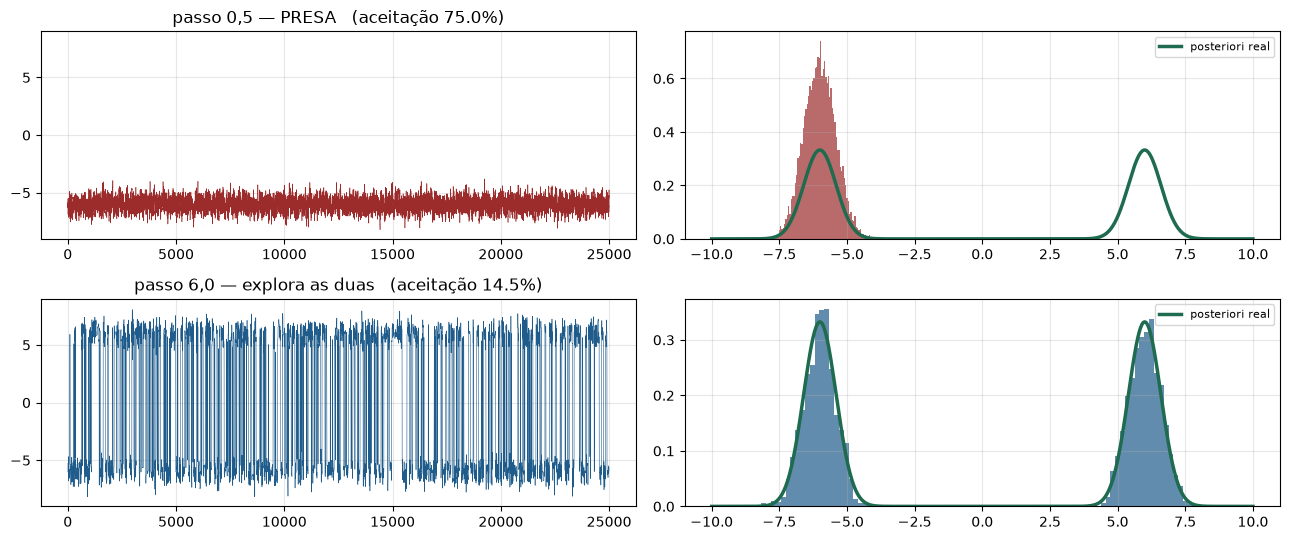

cadeia com passo 0,5: média = -6.003  (a média REAL da posteriori é 0,0)
cadeia com passo 6,0: média = +0.015

A primeira cadeia tem aceitação alta, trace 'estável' e resultado ERRADO.


In [7]:
def log_post_bimodal(theta):
    x = theta[0]
    return np.log(0.5 * stats.norm.pdf(x, -6, 0.6) + 0.5 * stats.norm.pdf(x, 6, 0.6) + 1e-300)


cad_ruim, tx_ruim = metropolis(log_post_bimodal, [-6.0], 25_000, 0.5, semente=2)
cad_boa, tx_boa = metropolis(log_post_bimodal, [-6.0], 25_000, 6.0, semente=2)

fig, axes = plt.subplots(2, 2, figsize=(13, 5.5))
gx = np.linspace(-10, 10, 800)
verdade = 0.5 * stats.norm.pdf(gx, -6, 0.6) + 0.5 * stats.norm.pdf(gx, 6, 0.6)

for i, (cad, tx, rotulo) in enumerate([(cad_ruim, tx_ruim, "passo 0,5 — PRESA"),
                                       (cad_boa, tx_boa, "passo 6,0 — explora as duas")]):
    axes[i, 0].plot(cad[:, 0], color=AZUL if i else VERMELHO, lw=0.4)
    axes[i, 0].set_title(f"{rotulo}   (aceitação {tx:.1%})")
    axes[i, 0].set_ylim(-9, 9)
    axes[i, 1].hist(cad[3000:, 0], bins=90, density=True,
                    color=AZUL if i else VERMELHO, alpha=0.7)
    axes[i, 1].plot(gx, verdade, color=VERDE, lw=2.5, label="posteriori real")
    axes[i, 1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"cadeia com passo 0,5: média = {cad_ruim[3000:, 0].mean():+.3f}  "
      f"(a média REAL da posteriori é 0,0)")
print(f"cadeia com passo 6,0: média = {cad_boa[3000:, 0].mean():+.3f}")
print("\nA primeira cadeia tem aceitação alta, trace 'estável' e resultado ERRADO.")

**Esse é o modo de falha mais perigoso.** A cadeia presa tem aceitação
saudável, trace que parece perfeitamente estacionário e $\hat{R}$ de 1,00 se
você rodar todas as cadeias do mesmo ponto. Nada denuncia o problema exceto
**iniciar de pontos dispersos**.

**Checklist mínimo antes de acreditar em qualquer MCMC:**

| Diagnóstico | Alvo |
|---|---|
| trace plot | ruído branco, sem tendência nem degraus |
| taxa de aceitação | 20% a 50% |
| $\hat{R}$ (≥ 4 cadeias, inícios dispersos) | < 1,01 |
| ESS por parâmetro | > 400 |
| posteriori vs. caso analítico conhecido | bate |

## 7. Por que ninguém usa Metropolis em produção

Metropolis tateia: a proposta é isotrópica e ignora a geometria da posteriori.
Em dimensão alta, quase toda direção é ruim, e a taxa de aceitação despenca.

**HMC/NUTS** — o que Stan, PyMC e NumPyro usam — utiliza o **gradiente** da
log-posteriori para simular uma trajetória física e propor saltos longos e
bem direcionados. Em 50 dimensões, a diferença de eficiência é de ordens de
grandeza.

Mas a lógica de aceitar/rejeitar continua sendo exatamente a que você
implementou aqui. Entender Metropolis é entender o que NUTS faz melhor.

In [8]:
print("Escalabilidade aproximada de Metropolis com passeio aleatório:\n")
print(f"{'dimensões':>10s} {'aceitação típica':>18s} {'ESS relativo':>14s}")
for d, acc, ess in [(1, "44%", "alto"), (5, "30%", "médio"),
                    (20, "23%", "baixo"), (100, "<10%", "impraticável")]:
    print(f"{d:>10d} {acc:>18s} {ess:>14s}")
print("\nHMC/NUTS mantém eficiência útil em centenas de dimensões.")

Escalabilidade aproximada de Metropolis com passeio aleatório:

 dimensões   aceitação típica   ESS relativo
         1                44%           alto
         5                30%          médio
        20                23%          baixo
       100               <10%   impraticável

HMC/NUTS mantém eficiência útil em centenas de dimensões.


## O que levar deste notebook

- MCMC funciona porque **$P(D)$ cancela na razão de aceitação**.
- O algoritmo cabe em 15 linhas; a dificuldade toda está no **diagnóstico**.
- **Valide contra um caso analítico** antes de confiar na sua implementação.
- **Tamanho do passo é o hiperparâmetro crítico** — mire 20–50% de aceitação.
- **Reparametrize** parâmetros restritos (use $\log\sigma$) e **inclua o jacobiano**.
- Rode **múltiplas cadeias de pontos dispersos**: é a única defesa contra
  multimodalidade.
- Em produção, use PyMC/Stan/NumPyro — mas sabendo o que eles fazem.

→ Próximo: o notebook de **exercícios** do módulo.